In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os

for root, dirs, files in os.walk("/content"):
    if "train_ratings.csv" in files:
        print("FOUND train_ratings.csv in:", root)
    if "neural_cf.ipynb" in files:
        print("FOUND neural_cf.ipynb in:", root)

FOUND train_ratings.csv in: /content/drive/Othercomputers/我的 Mac/Desktop/DS4420/group work
FOUND neural_cf.ipynb in: /content/drive/Othercomputers/我的 Mac/Desktop/DS4420/group work


In [17]:
WORKDIR = "/content/drive/Othercomputers/我的 Mac/Desktop/DS4420/group work"

import os
os.chdir(WORKDIR)

print("Current directory:", os.getcwd())
print(os.listdir())

Current directory: /content/drive/Othercomputers/我的 Mac/Desktop/DS4420/group work
['Project Literature Review.pdf', 'DS_4420_Spring_2026_Project_Guidelines (1).pdf', '1.png', '2.png', '3.png', '4.png', '5.png', 'movies.dat', 'ratings.dat', 'users.dat', '.ipynb_checkpoints', 'train_ratings.csv', 'val_ratings.csv', 'test_ratings.csv', 'make_split_file.ipynb', 'neural_cf.ipynb']


In [18]:
import gc
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [33]:
SEED = 42
DEVICE = torch.device("cpu")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

print("Torch version:", torch.__version__)
print("Device:", DEVICE)

Torch version: 2.10.0+cpu
Device: cpu


In [81]:
TRAIN_PATH = "train_ratings.csv"
VAL_PATH = "val_ratings.csv"
TEST_PATH = "test_ratings.csv"

DEBUG_SAMPLE = False

EMBED_DIM = 16
HIDDEN_UNITS = (32,)
DROPOUT_RATE = 0.0

BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
PATIENCE = 3

In [82]:
def load_split(train_path=TRAIN_PATH, val_path=VAL_PATH, test_path=TEST_PATH):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    expected_cols = {"user_id", "movie_id", "rating"}
    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        missing = expected_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} split is missing columns: {missing}")

    return train_df, val_df, test_df


def maybe_sample(train_df, val_df, test_df, debug_sample=DEBUG_SAMPLE):
    if not debug_sample:
        return train_df.copy(), val_df.copy(), test_df.copy()

    train_df = train_df.sample(
        n=min(DEBUG_TRAIN_N, len(train_df)),
        random_state=SEED
    ).reset_index(drop=True)

    val_df = val_df.sample(
        n=min(DEBUG_VAL_N, len(val_df)),
        random_state=SEED
    ).reset_index(drop=True)

    test_df = test_df.sample(
        n=min(DEBUG_TEST_N, len(test_df)),
        random_state=SEED
    ).reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = load_split()
print("Original sizes:")
print(len(train_df), len(val_df), len(test_df))

train_df, val_df, test_df = maybe_sample(train_df, val_df, test_df, debug_sample=DEBUG_SAMPLE)
print("After debug sample:")
print(len(train_df), len(val_df), len(test_df))

Original sizes:
800204 100002 100003
After debug sample:
800204 100002 100003


In [83]:
def filter_seen_entities(train_df, val_df, test_df):
    train_users = set(train_df["user_id"].unique())
    train_movies = set(train_df["movie_id"].unique())

    val_df = val_df[
        val_df["user_id"].isin(train_users) & val_df["movie_id"].isin(train_movies)
    ].reset_index(drop=True)

    test_df = test_df[
        test_df["user_id"].isin(train_users) & test_df["movie_id"].isin(train_movies)
    ].reset_index(drop=True)

    return train_df.reset_index(drop=True), val_df, test_df


train_df, val_df, test_df = filter_seen_entities(train_df, val_df, test_df)

print("After filtering unseen users/movies:")
print(len(train_df), len(val_df), len(test_df))

After filtering unseen users/movies:
800204 100002 100003


In [84]:
def build_id_maps(train_df):
    user_ids = np.sort(train_df["user_id"].unique())
    movie_ids = np.sort(train_df["movie_id"].unique())

    user2idx = {u: i for i, u in enumerate(user_ids)}
    movie2idx = {m: i for i, m in enumerate(movie_ids)}

    return user2idx, movie2idx


def encode_df(df, user2idx, movie2idx):
    x_user = df["user_id"].map(user2idx).to_numpy(dtype=np.int64)
    x_movie = df["movie_id"].map(movie2idx).to_numpy(dtype=np.int64)
    y = df["rating"].to_numpy(dtype=np.float32)

    return x_user, x_movie, y


user2idx, movie2idx = build_id_maps(train_df)

x_user_train, x_movie_train, y_train = encode_df(train_df, user2idx, movie2idx)
x_user_val, x_movie_val, y_val = encode_df(val_df, user2idx, movie2idx)
x_user_test, x_movie_test, y_test = encode_df(test_df, user2idx, movie2idx)

print("n_users:", len(user2idx))
print("n_movies:", len(movie2idx))
print("train shape:", x_user_train.shape, x_movie_train.shape, y_train.shape)

n_users: 6040
n_movies: 3706
train shape: (800204,) (800204,) (800204,)


In [85]:
def make_loader(x_user, x_movie, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = TensorDataset(
        torch.from_numpy(x_user).long(),
        torch.from_numpy(x_movie).long(),
        torch.from_numpy(y).float()
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)


train_loader = make_loader(x_user_train, x_movie_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(x_user_val, x_movie_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_loader(x_user_test, x_movie_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

In [86]:
class NeuralCF(nn.Module):
    def __init__(self, n_users, n_movies, embed_dim=EMBED_DIM, hidden_units=HIDDEN_UNITS, dropout_rate=DROPOUT_RATE):
        super().__init__()

        self.user_embedding = nn.Embedding(n_users, embed_dim)
        self.movie_embedding = nn.Embedding(n_movies, embed_dim)

        layers_list = []
        input_dim = embed_dim * 2

        for units in hidden_units:
            layers_list.append(nn.Linear(input_dim, units))
            layers_list.append(nn.ReLU())
            if dropout_rate > 0:
                layers_list.append(nn.Dropout(dropout_rate))
            input_dim = units

        layers_list.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers_list)

    def forward(self, user_idx, movie_idx):
        user_vec = self.user_embedding(user_idx)
        movie_vec = self.movie_embedding(movie_idx)
        x = torch.cat([user_vec, movie_vec], dim=1)
        out = self.mlp(x).squeeze(1)
        return out


model = NeuralCF(
    n_users=len(user2idx),
    n_movies=len(movie2idx),
    embed_dim=EMBED_DIM,
    hidden_units=HIDDEN_UNITS,
    dropout_rate=DROPOUT_RATE
).to(DEVICE)

print(model)

NeuralCF(
  (user_embedding): Embedding(6040, 16)
  (movie_embedding): Embedding(3706, 16)
  (mlp): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [87]:
def clip_predictions(preds, low=1.0, high=5.0):
    return np.clip(preds, low, high)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

@torch.no_grad()
def evaluate(model, loader, device=DEVICE):
    model.eval()

    all_preds = []
    all_true = []

    for user_idx, movie_idx, rating in loader:
        user_idx = user_idx.to(device)
        movie_idx = movie_idx.to(device)
        rating = rating.to(device)

        preds = model(user_idx, movie_idx)

        preds_np = preds.cpu().numpy()
        rating_np = rating.cpu().numpy()

        preds_np = clip_predictions(preds_np, 1.0, 5.0)

        all_preds.append(preds_np)
        all_true.append(rating_np)

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)

    return rmse(y_true, y_pred), y_true, y_pred

In [88]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE, patience=PATIENCE, device=DEVICE):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {"train_rmse": [], "val_rmse": []}

    best_val_rmse = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()

        train_preds = []
        train_true = []

        for user_idx, movie_idx, rating in train_loader:
            user_idx = user_idx.to(device)
            movie_idx = movie_idx.to(device)
            rating = rating.to(device)

            optimizer.zero_grad()
            preds = model(user_idx, movie_idx)
            loss = criterion(preds, rating)
            loss.backward()
            optimizer.step()

            train_preds.append(preds.detach().cpu().numpy())
            train_true.append(rating.detach().cpu().numpy())

        train_preds = np.concatenate(train_preds)
        train_true = np.concatenate(train_true)
        train_preds = clip_predictions(train_preds, 1.0, 5.0)
        train_rmse = rmse(train_true, train_preds)

        val_rmse, _, _ = evaluate(model, val_loader, device=device)

        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        print(f"Epoch {epoch:02d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [89]:
gc.collect()
set_seed(SEED)

model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    device=DEVICE
)

Epoch 01 | Train RMSE: 1.0547 | Val RMSE: 0.9386
Epoch 02 | Train RMSE: 0.9244 | Val RMSE: 0.9212
Epoch 03 | Train RMSE: 0.9112 | Val RMSE: 0.9171
Epoch 04 | Train RMSE: 0.9056 | Val RMSE: 0.9154
Epoch 05 | Train RMSE: 0.9019 | Val RMSE: 0.9146
Epoch 06 | Train RMSE: 0.8988 | Val RMSE: 0.9138
Epoch 07 | Train RMSE: 0.8961 | Val RMSE: 0.9149
Epoch 08 | Train RMSE: 0.8936 | Val RMSE: 0.9121
Epoch 09 | Train RMSE: 0.8912 | Val RMSE: 0.9104
Epoch 10 | Train RMSE: 0.8889 | Val RMSE: 0.9115


In [90]:
val_rmse, _, _ = evaluate(model, val_loader, device=DEVICE)
test_rmse, y_test_final, y_pred_final = evaluate(model, test_loader, device=DEVICE)

print("Final results:")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE:       {test_rmse:.4f}")

Final results:
Validation RMSE: 0.9104
Test RMSE:       0.9051


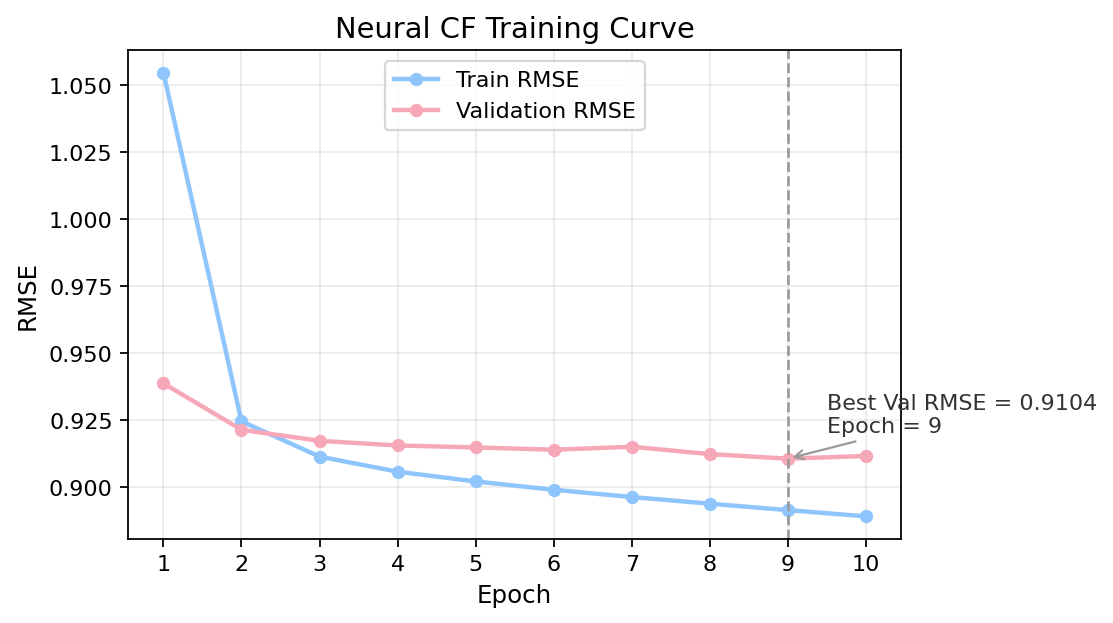

In [91]:
train_rmse = history["train_rmse"]
val_rmse = history["val_rmse"]
epochs = np.arange(1, len(train_rmse) + 1)

best_epoch = int(np.argmin(val_rmse)) + 1
best_val = min(val_rmse)

train_color = "#8EC5FC"
val_color = "#F7A8B8"
line_color = "#999999"

plt.figure(figsize=(7, 4), dpi=160)

plt.plot(
    epochs, train_rmse,
    marker="o",
    linewidth=2,
    markersize=5,
    color=train_color,
    label="Train RMSE"
)

plt.plot(
    epochs, val_rmse,
    marker="o",
    linewidth=2,
    markersize=5,
    color=val_color,
    label="Validation RMSE"
)

plt.axvline(best_epoch, linestyle="--", linewidth=1.2, color=line_color)

plt.annotate(
    f"Best Val RMSE = {best_val:.4f}\nEpoch = {best_epoch}",
    xy=(best_epoch, best_val),
    xytext=(best_epoch + 0.5, best_val + 0.01),
    arrowprops=dict(arrowstyle="->", lw=1, color=line_color),
    fontsize=10,
    color="#333333"
)

plt.xlabel("Epoch", fontsize=11)
plt.ylabel("RMSE", fontsize=11)
plt.title("Neural CF Training Curve", fontsize=13)
plt.xticks(epochs)
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("neural_cf_training_curve_pastel.png", dpi=200, bbox_inches="tight")
plt.show()